work flow

1. importing data set
2. data analysis
3. data cleaing
4. data preprocessing
5. train test split
6. model selection & training -> Random forest
7. model evaluation
8. predictive modeling



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

1. data collection and loading


In [4]:
gold_data = pd.read_csv('gld_price_data.csv')
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


spx -> this the stock price index
gld -> this is the gold price index
USO -> this is the oil price index
SLV -> this is the silver price index
EUR / USD -> this is the exchange rate of euro to dollar


In [ ]:
2. data analysis

In [5]:
gold_data.shape

(2290, 6)

In [6]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [7]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


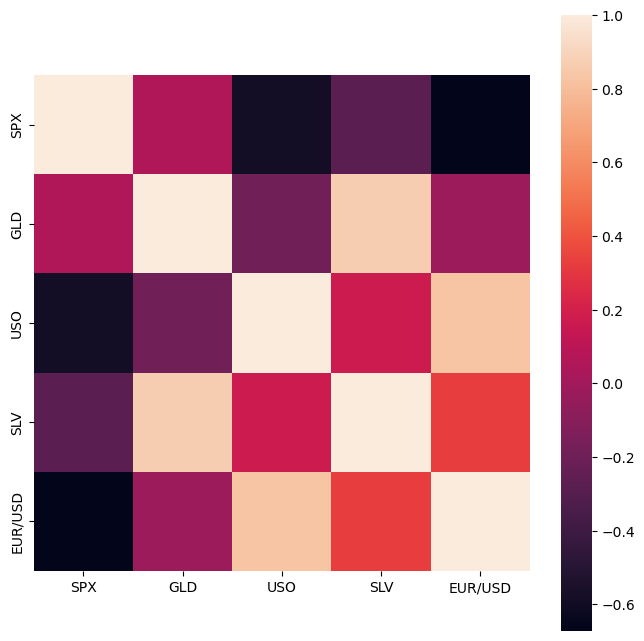

In [16]:
correlation_matrix = gold_data.drop('Date', axis=1).corr()
plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix, cbar=True, square=True)
plt.show()

checking the distribution of the data set

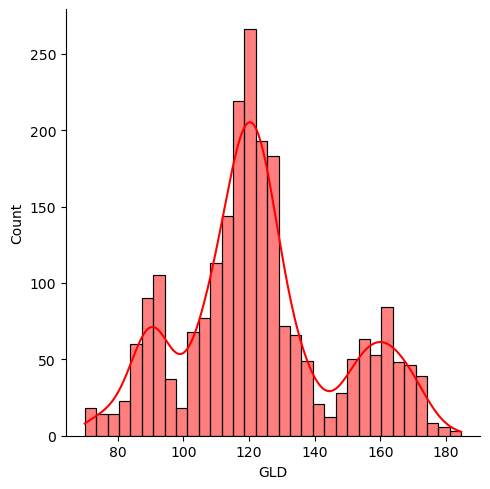

In [20]:
sns.displot(gold_data['GLD'], color='red', kde=True)

3. data cleaning 
A per now there is no data cleaning required as there are no null values in the data set.


4. Data Preprocessing

In [22]:
x = gold_data.drop(['Date', "GLD"], axis=1)
y = gold_data['GLD']

print(x)
print(y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


5. Train test split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=12)


6. model training and selection

In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=12)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=12)

prediction

In [25]:
test_data_prediction = model.predict(x_test)
print(test_data_prediction)

[121.13120092 116.66309998 159.0998017  167.10509843 148.66439906
 125.06400059 128.72380134  87.91429926  90.86029797 132.10180289
 117.42190101 172.06190109 145.26349941 120.60700206 122.42479949
 123.50750028  90.92159905  90.23520032  93.82880033 168.35369864
 113.59390058 119.24960009 110.10979944 139.61100059 127.99459889
  88.90309857 145.37499896 127.85659911 124.85910074  80.60540073
  84.31670041 134.254102   146.01179906 150.45519994  83.59889954
 132.83710095 155.16300366 108.95559995 127.71349908 122.36671343
 164.0477026  113.32109912 111.08740015 132.69630136 112.54550101
  76.41960168 147.00680027 113.67519945 117.88210131 117.47890118
 119.27640032 157.31940092  87.73249934 128.50489851 102.67309926
  90.97200066 155.34050102 113.92789956 118.88570066 122.45779907
 149.94059747 118.39680054 130.79790072 117.68109956 171.83880243
 156.01819827 151.60170162 103.1360012  156.86509968 135.73820152
 148.39840074  99.22209946 120.9860995  153.81480096 132.42910141
 121.46870

7. Evaluating the model

In [26]:
error_score = metrics.r2_score(y_test, test_data_prediction)
print('R squared error : ', error_score)

R squared error :  0.983896009775526


comparing the actual values and predicted values

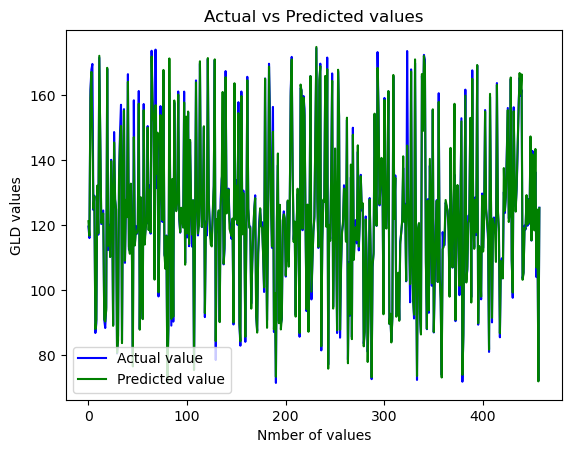

In [27]:
y_test = list(y_test)


plt.plot(y_test, color = 'blue', label = 'Actual value')
plt.plot(test_data_prediction, color='green', label='Predicted value')
plt.xlabel('Nmber of values')
plt.ylabel("GLD values")
plt.legend()
plt.title("Actual vs Predicted values")
plt.show()